In [31]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
import matplotlib.pyplot as plt
from word2number import w2n
from dotenv import load_dotenv


# Load dataset

In [32]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "simpsons")

# Set paths relative to base_dir
annotation_path = os.path.join(base_dir, "v1_Annotation_Val_simpsons_vqa.json")
question_path = os.path.join(base_dir, "v1_Question_Val_simpsons_vqa.json")
images_dir = os.path.join(base_dir, "val_images")

def load_dataset(annotation_path, question_path):
    try:
        with open(annotation_path, 'r') as f:
            annotations = json.load(f)['annotations']

        with open(question_path, 'r') as f:
            questions = json.load(f)['questions']

        # Select high-quality QA pairs (overall_scores == 1.0)
        filtered_annotations = [
            annotation for annotation in annotations
            if annotation.get('overall_scores', {}).get('question') == 1.0 and
               annotation.get('overall_scores', {}).get('answer') == 1.0
        ]

        # Create a mapping from question ID to answer
        question_id_to_answer = {
            annotation['id']: annotation['answer']
            for annotation in filtered_annotations
        }

        # Create a mapping from question ID to answer type
        question_id_to_answer_type = {
            annotation['id']: {
                'answer': annotation['answer'],
                'answer_type': annotation.get('answer_type', 'other')
            }
            for annotation in filtered_annotations
        }

        filtered_questions = [question for question in questions if question['id'] in question_id_to_answer]

        return filtered_questions, filtered_annotations, question_id_to_answer, question_id_to_answer_type

    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], [], {}, {}

def get_dataset(questions, question_id_to_answer, fraction=0.005, seed=42):
    # TODO：Increase quantity
# def get_dataset(questions, question_id_to_answer, fraction=0.05, seed=42):
    try:
        random.seed(seed)
        sample_size = max(1, int(len(questions) * fraction))
        sampled_question_items = random.sample(questions, sample_size)
        sampled_correct_answers = [
            question_id_to_answer[q['id']]
            for q in sampled_question_items
        ]
        # Add image_base64 to each sampled question
        for q in sampled_question_items:
            image_relative_path = q['img_path']
            image_path = os.path.join(images_dir, image_relative_path)
            q['image_base64'] = encode_image(image_path)

        return sampled_question_items, sampled_correct_answers

    except Exception as e:
        print(f"Error sampling dataset: {e}")
        return [], []

def encode_image(image_path):
    try:
        if not os.path.exists(image_path):
            print(f"Error: The image file at {image_path} was not found.")
            return None

        with open(image_path, "rb") as image_file:
            image_base64 = base64.b64encode(image_file.read()).decode('utf-8')
            return image_base64

    except Exception as e:
        print(f"An error occurred while encoding the image: {e}")
        return None

# Initialize results list
results_ablation = []

# Ablation Study Configuration
# Global variables for agent enablement, initialized here
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_HALLUCINATION_AGENT = False


# Agents Configuration

In [33]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# Enhanced Visual agent that provides highly accurate and question-relevant descriptions
def visual_agent(image_base64, question, max_retries=3, retry_delay=2):
    # If visual agent is disabled, return a basic placeholder
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from The Simpsons."

    prompt = f"""
    You are a cartoon visual analysis expert. Analyze the given image and generate a **concise and factual visual description**. 
    Your response must be based **only on what is visibly present in the image**. 

    Task: Generate a short, grounded visual description based on the image.

    Remember to focus on visual elements that might help answer this specific question: 
    **{question}**

    Strictly follow these guidelines:
    - Limit your description to **3–4 sentences maximum**
    - Use **simple, clear language** and avoid redundancy
    - Mention only:
        1. Characters: Visible characters with notable visual traits
        2. Actions: What they are doing (body posture, gestures)
        3. Scene: Indoor/outdoor, main environment
        4. Key Objects: Only if directly relevant (e.g., items being used or interacted with)
        5. Positions: Where things are (e.g., "on the left", "in the background")

    Do not include:
    - Opinions, guesses, or emotions
    - Storyline interpretation or external context
    - Unnecessary details (e.g., background clutter)

    Be concise. Stay grounded in what is visible only.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}},
                            ],
                        }
                    ],
                    max_tokens=1500,  
                    temperature=0.1,
                )
                visual_desc = completion.choices[0].message.content.strip()
                return visual_desc
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=1500,  
                    temperature=0.1,
                )
                visual_desc = completion.content[0].text.strip()
                return visual_desc

        except Exception as e:
            print(f"Visual agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Visual agent failed to process the image")
    return None

# Language agent: handles text-related tasks, and outputs initial predicted answer
def language_agent(question, image_base64, visual_desc, max_retries=3, retry_delay=2):
    # If language agent is disabled, return None
    if not ENABLE_LANGUAGE_AGENT:
        return None
    # Note: visual_desc is always available regardless of whether visual agent is enabled or not
    # - If visual agent is enabled: visual_desc contains the generated description
    # - If visual agent is disabled: visual_desc contains "This is a cartoon image from The Simpsons."
    prompt = f"""
    As a cartoon language expert, answer the question based on the provided context using EXACTLY ONE WORD:

    Input:
    Question: {question}
    Visual Description: {visual_desc}

    Guidelines: No explanations or punctuation allowed.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=150,
                    temperature=0.1,
                )
                initial_predicted_answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.1,
                )
                initial_predicted_answer = completion.content[0].text.strip().lower()

            # Process the response
            # 1. Remove punctuation marks
            initial_predicted_answer = initial_predicted_answer.rstrip('.!?')

            # 2. Split into words and get the first word
            words = initial_predicted_answer.split()
            if not words:
                continue

            initial_predicted_answer = words[0]

            # 3. Convert numbers if applicable
            try:
                # Check if word represents a number
                number = w2n.word_to_num(initial_predicted_answer)
                initial_predicted_answer = str(number)
            except ValueError:
                # Check if contains numeric digits
                matches = re.findall(r'\d+', initial_predicted_answer)
                if matches:
                    initial_predicted_answer = matches[0]

            return initial_predicted_answer

        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

# Hallucination detection agent: improved implementation with visual agent coordination
def hallucination_agent(question, image_base64, initial_predicted_answer, visual_desc, max_retries=3, retry_delay=2):
    # If hallucination agent is disabled, return the initial prediction
    if not ENABLE_HALLUCINATION_AGENT:
        return initial_predicted_answer
    
    # Handle case when language_agent failed or was disabled
    if initial_predicted_answer is None:
        return "unknown"
    
    # First round: Critic evaluates the initial answer
    prompt_first_round = f"""
    As an expert cartoon visual critic, evaluate the accuracy of the initial answer to this visual question.
    
    Question: {question}
    Initial Answer: {initial_predicted_answer}
    Visual Description: {visual_desc}
    
    EVALUATION FRAMEWORK:
    
    1. UNDERSTAND THE QUESTION REQUIREMENTS
    2. EXAMINE VISUAL EVIDENCE
    3. EVALUATE THE ANSWER'S ACCURACY using this scale:
       - 1.0: Completely correct answer that addresses the question perfectly
       - 0.75: Mostly correct with only minor differences
       - 0.5: Partially correct - contains some correct elements but misses important aspects
       - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
       - 0.0: Completely incorrect
    
    YOUR RESPONSE MUST USE THIS FORMAT:
    ACCURACY: [1.0/0.75/0.5/0.25/0.0]
    EXPLANATION: [brief explanation of why the answer is appropriate or not]
    RECOMMENDATION: [KEEP/REVISE]
    CONFIDENCE: [HIGH/LOW] (HIGH if accuracy is 0.75 or higher, LOW otherwise)
    CORRECTION: [suggest a better answer if recommendation is REVISE, otherwise write 'none']
    VISUAL_EVIDENCE: [list specific elements from the visual description that support your conclusion]
    """
    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt_first_round},
                            {"type": "image_url", 
                            "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=300,
                    temperature=0.1,
                )
                first_response = completion.choices[0].message.content.strip()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt_first_round},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/jpeg",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=300,
                    temperature=0.1,
                )
                first_response = completion.content[0].text.strip()
            
            # Parse the critic's evaluation
            accuracy_match = re.search(r'ACCURACY:\s*(1\.0|0\.75|0\.5|0\.25|0\.0)', first_response, re.IGNORECASE)
            explanation_match = re.search(r'EXPLANATION:\s*(.+?)(?=\n(RECOMMENDATION|CONFIDENCE|CORRECTION|VISUAL_EVIDENCE)|$)', first_response, re.IGNORECASE | re.DOTALL)
            recommendation_match = re.search(r'RECOMMENDATION:\s*(KEEP|REVISE)', first_response, re.IGNORECASE)
            confidence_match = re.search(r'CONFIDENCE:\s*(HIGH|LOW)', first_response, re.IGNORECASE)
            correction_match = re.search(r'CORRECTION:\s*(.+?)(?=\n(VISUAL_EVIDENCE)|$)', first_response, re.IGNORECASE | re.DOTALL)
            visual_evidence_match = re.search(r'VISUAL_EVIDENCE:\s*(.+?)(?=\n|$)', first_response, re.IGNORECASE | re.DOTALL)
            
            # Extract values with fallbacks
            accuracy = 0.5 if not accuracy_match else float(accuracy_match.group(1))
            explanation = "No explanation provided" if not explanation_match else explanation_match.group(1).strip()
            recommendation = "KEEP" if not recommendation_match else recommendation_match.group(1).upper()
            confidence = "LOW" if accuracy < 0.75 else "HIGH"
            if confidence_match:
                confidence = confidence_match.group(1).upper()
            correction = initial_predicted_answer if not correction_match or correction_match.group(1).strip().lower() == "none" else correction_match.group(1).strip()
            visual_evidence = "" if not visual_evidence_match else visual_evidence_match.group(1).strip()
            
            # If ENABLE_VISUAL_AGENT is true, add coordination with visual agent
            if ENABLE_VISUAL_AGENT:
                # Import the agent consistency analyzer from similarity_utils if available
                try:
                    from similarity_utils import analyze_agent_consistency
                    
                    # Analyze consistency between visual and hallucination agents
                    consistency_analysis = analyze_agent_consistency(
                        visual_desc=visual_desc,
                        halluc_answer=correction if recommendation == "REVISE" else initial_predicted_answer,
                        initial_answer=initial_predicted_answer
                    )
                    
                    # Adjust decision based on consistency analysis
                    if consistency_analysis['recommend_agent'] == 'language':
                        # Visual evidence supports language agent's initial answer
                        if recommendation == "REVISE":
                            # Override hallucination agent's recommendation
                            recommendation = "KEEP"
                            correction = initial_predicted_answer
                            confidence = "MEDIUM" # Adjusted confidence
                    elif consistency_analysis['recommend_agent'] == 'hallucination':
                        # Visual evidence supports hallucination agent's correction
                        confidence = "HIGH" if consistency_analysis['confidence'] == 'high' else confidence
                    elif consistency_analysis['recommend_agent'] == 'combined' and recommendation == "REVISE":
                        # Try to combine insights from both agents
                        confidence = "MEDIUM"
                except ImportError:
                    # Fallback if the function is not available
                    pass
            
            # If recommendation is KEEP, just return the initial answer with confidence marker if needed
            if recommendation == "KEEP":
                if confidence == "LOW":
                    return f"[LOW CONFIDENCE] {initial_predicted_answer.lower().strip().rstrip('.!?')}"
                return initial_predicted_answer.lower().strip().rstrip('.!?')
            
            # If recommendation is REVISE, go for second round evaluation
            prompt_second_round = f"""
            As an expert cartoon visual validator, make a final decision about the answer to this question.
            
            Question: {question}
            Initial Answer: {initial_predicted_answer}
            Critic's Assessment: {explanation}
            Suggested Correction: {correction}
            Visual Evidence: {visual_evidence}
            
            Based on the image, provide the MOST ACCURATE single-word answer.
            
            YOUR RESPONSE FORMAT:
            FINAL_ANSWER: [single word answer]
            CONFIDENCE: [HIGH/MEDIUM/LOW]
            RATIONALE: [brief explanation of your final decision]
            """
            
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt_second_round},
                            {"type": "image_url", 
                            "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.1,
                )
                second_response = completion.choices[0].message.content.strip()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt_second_round},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/jpeg",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.1,
                )
                second_response = completion.content[0].text.strip()
            
            # Parse the second response
            final_answer_match = re.search(r'FINAL_ANSWER:\s*(.+?)(?=\n|$)', second_response, re.IGNORECASE)
            final_confidence_match = re.search(r'CONFIDENCE:\s*(HIGH|MEDIUM|LOW)', second_response, re.IGNORECASE)
            rationale_match = re.search(r'RATIONALE:\s*(.+?)(?=\n|$)', second_response, re.IGNORECASE)
            
            final_answer = correction if not final_answer_match else final_answer_match.group(1).strip()
            final_confidence = confidence if not final_confidence_match else final_confidence_match.group(1).upper()
            
            # Format and return the final answer
            final_answer = final_answer.lower().strip().rstrip('.!?')
            if final_confidence == "LOW":
                return f"[LOW CONFIDENCE] {final_answer}"
            return final_answer
            
        except Exception as e:
            # Silent error handling, just write to log without detailed output
            print(f"Hallucination agent error: {str(e)[:100]}..." if len(str(e)) > 100 else f"Hallucination agent error: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)  # Added the proper wait between retry attempts
            # Fallback to initial answer with low confidence marker
            if attempt == max_retries - 1:
                return f"[LOW CONFIDENCE] {initial_predicted_answer.lower().strip().rstrip('.!?')}"

Using OpenAI model: gpt-4o-mini


# Calculate accuracy

In [34]:
def compute_accuracy(question, correct_answer, predicted_answer, answer_type, max_retries=2, retry_delay=2, num_evaluations=3):
    if correct_answer.lower().strip() == predicted_answer.lower().strip():
        return 1.0, [1.0] * num_evaluations

    if correct_answer.lower().strip() + 's' == predicted_answer.lower().strip() or predicted_answer.lower().strip() + 's' == correct_answer.lower().strip():
        return 0.75, [0.75] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Answer type: {answer_type}
        Correct answer: {correct_answer}
        Predicted answer: {predicted_answer}
        
        Evaluation Rules:
        1. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].
        2. Answer Type Considerations:
        - Yes/No: Must be exactly correct (1.0) or wrong (0.0)
        - Number: Must be exactly correct (1.0) or wrong (0.0)
        - Other: Focus PRIMARILY on semantic similarity:

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.1
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.1
                    )
                    response = completion.content[0].text.strip()

                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0

                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue
                # If all retries for this evaluation fail, continue to next evaluation

    # If all evaluations failed, return 0
    if not scores:
        return 0.0, []
        
    # Calculate the result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  # Get most common score
    
    # If there's a tie, calculate average of the tied values
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  # Average of tied scores
    
    return majority_score, scores

# Run experiment

In [35]:
# Run Multiple Configurations
# Define the configurations to test
configurations = [
    # Only Language agent
    {
        'visual': False,
        'language': True,
        'hallucination': False,
        'name': 'language'
    },
    # Visual + Language agents
    {
        'visual': True,
        'language': True,
        'hallucination': False,
        'name': 'visual_language'
    },
    # Language + Hallucination agents
    {
        'visual': False,
        'language': True,
        'hallucination': True,
        'name': 'language_hallucination'
    },
    # Visual + Language + Hallucination agents (all enabled)
    {
        'visual': True,
        'language': True,
        'hallucination': True,
        'name': 'visual_language_hallucination'
    }
]

def run_experiment(enable_visual, enable_language, enable_hallucination):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_HALLUCINATION_AGENT, results_ablation, accuracies

    # Store original configuration
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'hallucination': ENABLE_HALLUCINATION_AGENT
    }

    # Reset results storage
    results_ablation = []
    accuracies = []

    # Set configuration for this experiment
    ENABLE_VISUAL_AGENT = enable_visual
    ENABLE_LANGUAGE_AGENT = enable_language
    ENABLE_HALLUCINATION_AGENT = enable_hallucination

    # Create configuration name
    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_hallucination:
        config_parts.append("hallucination")
    
    config_name = "_".join(config_parts)

    # Define base column order - we'll adjust based on enabled agents
    base_columns = [
        'row_num',
        'question_id',
        'question',
        'answer_type',
        'correct_answer'
    ]
    
    # Conditionally add columns based on enabled agents
    column_order = base_columns.copy()
    
    if enable_visual:
        column_order.append('visual_desc')
        
    if enable_language and enable_hallucination:
        column_order.extend(['initial_predicted_answer', 'predicted_answer'])
    else:
        column_order.append('predicted_answer')
    
    column_order.extend(['evaluator_scores', 'accuracy'])

    try:
        # Initialize results storage
        accuracies = []

        # Load dataset
        questions, annotations, question_id_to_answer, question_id_to_answer_type = load_dataset(annotation_path, question_path)

        if not questions:
            print("The 'questions' list is empty or not a list.")
            raise ValueError("Questions list is empty")

        # Get sample data
        sampled_questions, sampled_correct_answers = get_dataset(questions, question_id_to_answer)

        if not sampled_questions:
            print("Failed to sample questions or empty sample")
            raise ValueError("No sampled questions")

        # Create an empty collection to store the processed problem IDs
        processed_question_ids = set() 

        # Process each question
        for i, (question_item, correct_answer) in enumerate(tqdm(zip(sampled_questions, sampled_correct_answers),
                                     total=len(sampled_questions))):
            try:
                question_id = question_item['id']
                # Skip if already processed this question
                if question_id in processed_question_ids:
                    continue
                    
                processed_question_ids.add(question_id)
                
                question = question_item['question']
                image_relative_path = question_item['img_path']
                answer_type = question_id_to_answer_type[question_id]['answer_type']

                print(f"\nProcessing question {i + 1}/{len(sampled_questions)}: ID {question_id}")

                # Build image path and encode
                image_path = os.path.join(images_dir, image_relative_path)
                image_base64 = encode_image(image_path)

                if image_base64 is None:
                    print(f"Skipping question ID {question_id} due to image encoding failure")
                    continue
                
                # Multi agent processing based on configuration
                # Step 1: Visual agent - now directly including question in the prompt
                visual_desc = visual_agent(image_base64, question=question)
                if visual_desc is None:
                    print(f"Skipping question ID {question_id} - Failed to get image description")
                    continue
                
                # Step 2: Language agent processes the question-aware visual description
                initial_predicted_answer = language_agent(question, image_base64, visual_desc)
                
                # If language agent is disabled or failed, use a default answer
                if initial_predicted_answer is None:
                    if not ENABLE_LANGUAGE_AGENT:
                        # Default answer when language agent is disabled
                        initial_predicted_answer = "unknown"  
                    else:
                        print(f"Skipping question ID {question_id} - Failed to generate answer")
                        continue

                # Step 3: Hallucination agent (may be disabled)
                final_answer = hallucination_agent(
                    question=question,
                    image_base64=image_base64,
                    initial_predicted_answer=initial_predicted_answer,
                    visual_desc=visual_desc
                )

                # Use final answer if available, otherwise fallback to initial
                model_answer = final_answer if final_answer else initial_predicted_answer

                # Calculate accuracy
                accuracy, scores = compute_accuracy(
                    question=question,
                    correct_answer=correct_answer,
                    predicted_answer=model_answer,
                    answer_type=answer_type
                )

                # Store result - create a base result dictionary with only necessary fields
                result = {
                    'question_id': question_id,
                    'question': question,
                    'answer_type': answer_type,
                    'correct_answer': correct_answer,
                    'predicted_answer': model_answer,
                    'evaluator_scores': ", ".join([str(s) for s in scores]),  
                    'accuracy': accuracy
                }
                
                # Conditionally add columns based on which agents are enabled
                if enable_visual:
                    result['visual_desc'] = visual_desc
                    
                if enable_language and enable_hallucination:
                    result['initial_predicted_answer'] = initial_predicted_answer

                results_ablation.append(result)
                accuracies.append(accuracy)

                # Print results with conditional output based on enabled agents
                print(f"Question ID: {question_id}")
                print(f"Question: {question}")
                print(f"Answer Type: {answer_type}")
                print(f"Correct Answer: {correct_answer}")
                
                # Only display visual description if visual agent is enabled
                if ENABLE_VISUAL_AGENT:
                    print(f"Visual Description: {visual_desc}")
                
                # Only display initial answer if language agent and hallucination agent are both enabled
                if ENABLE_LANGUAGE_AGENT and ENABLE_HALLUCINATION_AGENT:
                    print(f"Initial Answer: {initial_predicted_answer}")
                    print(f"Predicted Answer: {model_answer}")
                else:
                    print(f"Predicted Answer: {model_answer}")
                
                print(f"Evaluator Scores: {scores}")
                print(f"Accuracy: {accuracy:.4f}")

            except Exception as e:
                print(f"Error processing question {question_item.get('id', 'unknown')}: {e}")
                continue

        # Calculate average accuracy
        if accuracies:
            average_accuracy = np.mean(accuracies)
            print(f"Average Accuracy: {average_accuracy:.4f}")
        else:
            print("No valid accuracy data")
            average_accuracy = 0
        
        # Save results with the correct column order
        # Clean up results to remove any existing average rows
        results_to_save = [r for r in results_ablation if r.get('question_id') != 'Average']
        
        # Get unique questions
        unique_questions = len(set(r['question_id'] for r in results_to_save))
        
        # Add row numbers to each result
        for i, result in enumerate(results_to_save, 1):
            result['row_num'] = i
        
        # Add average accuracy as the last row
        average_result = {
            'row_num': len(results_to_save) + 1,
            'question_id': 'Average',
            'question': f'Total Questions: {unique_questions}',  
            'answer_type': 'All',  
            'correct_answer': '',
            'predicted_answer': '',
            'evaluator_scores': '',  
            'accuracy': average_accuracy
        }
        
        # Add conditional columns to the average row
        if enable_visual:
            average_result['visual_desc'] = ''
        
        if enable_language and enable_hallucination:
            average_result['initial_predicted_answer'] = ''
            
        results_to_save.append(average_result)
        
        # Save to CSV
        safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
        results_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(results_dir, exist_ok=True)
        os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
        
        # Save to ablation subdirectory with configuration in filename
        output_path = os.path.join(results_dir, "ablation", f'simpsons_ablation_{config_name}_{safe_model_name}.csv')
        
        # Try to create a DataFrame with only the columns that exist in our results
        try:
            results_df = pd.DataFrame(results_to_save)
            
            # Use only columns that exist in our results and are in our desired column order
            existing_columns = [col for col in column_order if col in results_df.columns]
            results_df = results_df[existing_columns]
            
            results_df.to_csv(output_path, index=False)
            print(f"Results for {config_name} configuration successfully saved to: {output_path}")
        except Exception as e:
            print(f"Error saving results for {config_name} to CSV: {e}")
        
        return results_ablation, average_accuracy

    except Exception as e:
        print(f"Unexpected error: {e}")
        average_accuracy = 0
        
        # Restore original configuration
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_HALLUCINATION_AGENT = original_config['hallucination']
        
        return [], average_accuracy
    
# Run all ablation experiments sequentially and store results
all_accuracies = {}
all_results = {}

for config in configurations:
    print(f"\n{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    results, accuracy = run_experiment(
        enable_visual=config['visual'],
        enable_language=config['language'],
        enable_hallucination=config['hallucination'],
    )
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue
    
    # Add the missing print statement for configuration completion
    print(f"Configuration {config['name']} finished with accuracy: {accuracy:.4f}")
    
    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results


Running configuration: language


  0%|          | 0/36 [00:00<?, ?it/s]


Processing question 1/36: ID 77311


  3%|▎         | 1/36 [00:03<01:57,  3.36s/it]

Question ID: 77311
Question: what is on the shelf?
Answer Type: other
Correct Answer: book
Predicted Answer: books
Evaluator Scores: [0.75, 0.75, 0.75]
Accuracy: 0.7500

Processing question 2/36: ID 12809


...

Question ID: 71583
Question: what is in the background?
Answer Type: other
Correct Answer: table
Visual Description: The image shows two cartoon hands, one yellow and one a darker shade, holding a purple bill labeled "LUCRETIA MOTT" with a portrait of a woman. In the background, there is a game board with various colorful spaces, including images of characters and symbols. The scene appears to be indoors, likely around a table where the game is being played. The focus is on the hands and the bill, with the game board visible beneath them.
Initial Answer: board
Predicted Answer: board
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.2500

Processing question 35/36: ID 37083


 97%|█████████▋| 35/36 [04:50<00:07,  7.82s/it]

Question ID: 37083
Question: what are the men doing?
Answer Type: other
Correct Answer: standing
Visual Description: Two cartoon men are standing in front of a red curtain in an indoor setting. The man on the left, wearing a light blue suit with a pink tie, appears to be gesturing with his left hand, while the man on the right, dressed in a dark blue suit, is looking at him. Both characters have distinct yellow skin and exaggerated facial features. They seem to be engaged in a conversation, likely discussing something related to the curtain or the stage behind it.
Initial Answer: talking
Predicted Answer: talking
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.2500

Processing question 36/36: ID 96818


100%|██████████| 36/36 [04:57<00:00,  8.26s/it]

Question ID: 96818
Question: what is the person sitting on?
Answer Type: other
Correct Answer: chair
Visual Description: The scene is set indoors at a dining table, where three characters are present: Marge, with blue hair and a green dress, Bart, wearing a red shirt, and Homer, in a white shirt. Homer is animatedly gesturing with his hands while sitting on a wooden chair. The table is set with plates of food, and a glass of water is visible in front of him.
Initial Answer: chair
Predicted Answer: chair
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000
Average Accuracy: 0.7569
Results for visual_language_hallucination configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_visual_language_hallucination_gpt_4o_mini.csv
Configuration visual_language_hallucination finished with accuracy: 0.7569


# Save results

In [44]:
# Save results for each configuration in the dictionary
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('question_id') != 'Average']
    
    # Get unique questions
    unique_questions = len(set(r['question_id'] for r in results_to_save))
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)
    
    # Add row numbers to each result
    for i, result in enumerate(results_to_save, 1):
        result['row_num'] = i
    
    # Define base column order - standard columns that always appear
    base_columns = [
        'row_num',
        'question_id',
        'question',
        'answer_type',
        'correct_answer'
    ]
    
    # Determine which optional columns to include based on the configuration name
    column_order = base_columns.copy()
    
    # Visual description is only included if "visual" is in config name
    if "visual" in config_name:
        column_order.append('visual_desc')
        
    # Only include both initial and predicted answer if both language and hallucination are enabled
    if "language" in config_name and "hallucination" in config_name:
        column_order.extend(['initial_predicted_answer', 'predicted_answer'])
    else:
        column_order.append('predicted_answer')
        
    # Always include these at the end
    column_order.extend(['evaluator_scores', 'accuracy'])
    
    # Create the average result row with only the necessary columns
    average_result = {
        'row_num': len(results_to_save) + 1,
        'question_id': 'Average',
        'question': f'Total Questions: {unique_questions}',  
        'answer_type': 'All',  
        'correct_answer': '',
        'predicted_answer': '',
        'evaluator_scores': '',  
        'accuracy': average_accuracy
    }
    
    # Add conditional columns to the average row
    if "visual" in config_name:
        average_result['visual_desc'] = ''
    
    if "language" in config_name and "hallucination" in config_name:
        average_result['initial_predicted_answer'] = ''
        
    results_to_save.append(average_result)
    
    # Save to CSV
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(results_dir, exist_ok=True)
    
    # Create ablation subdirectory if it doesn't exist
    os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
    
    # Save to ablation subdirectory with configuration in filename
    output_path = os.path.join(results_dir, "ablation", f'simpsons_ablation_{config_name}_{safe_model_name}.csv')
    
    # Try to create a DataFrame before file operations
    try:
        results_df = pd.DataFrame(results_to_save)
        
        # Filter to only include columns that exist in our results_df and are in our desired column_order
        filtered_columns = [col for col in column_order if col in results_df.columns]
        results_df = results_df[filtered_columns]
        
        # Check if the file exists and explicitly remove it
        if os.path.exists(output_path):
            try:
                os.remove(output_path)
                print(f"Existing file removed: {output_path}")
            except Exception as e:
                print(f"Error removing existing file: {e}")
        
        # Save the file
        results_df.to_csv(output_path, index=False)
        
        # Verify the file was created
        if os.path.exists(output_path):
            print(f"Results for {config_name} configuration successfully saved to: {output_path}")
        else:
            print(f"Warning: File for {config_name} was not created at {output_path}")
    except Exception as e:
        print(f"Error saving results for {config_name} to CSV: {e}")

# Visualization and Comparison

No accuracy results in memory. Attempting to load from CSV files...
Loaded accuracy for language: 0.7431
Loaded accuracy for visual_language: 0.7292
Loaded accuracy for language_hallucination: 0.7500
Loaded accuracy for visual_language_hallucination: 0.7569

Accuracy values used for visualization:
Language Only: 0.7431
Visual + Language: 0.7292
Language + Hallucination: 0.7500
Visual + Language + Hallucination: 0.7569


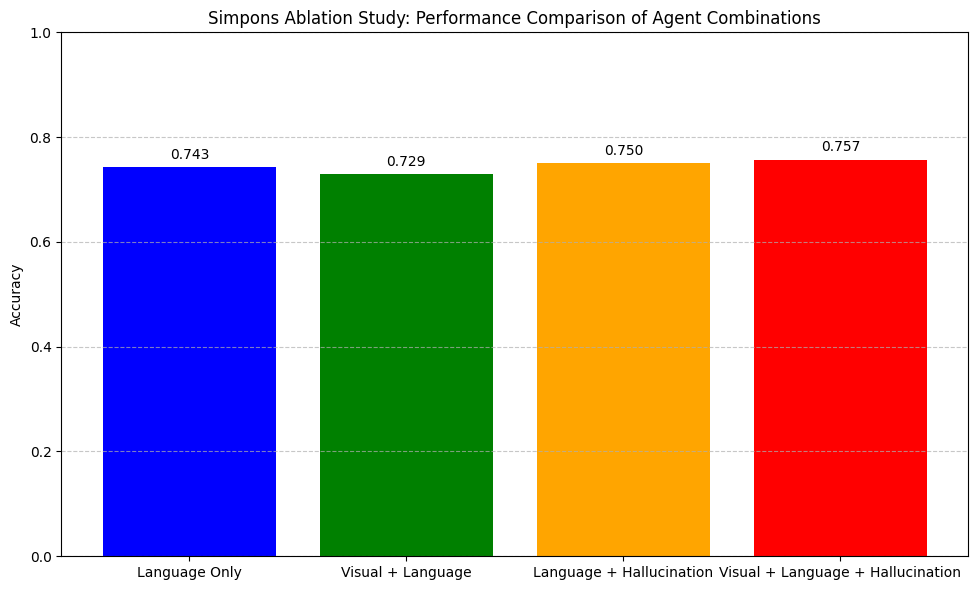


Comparison results saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/Simpons_ablation_comparison.csv
Final comparison data:
                       Configuration  Accuracy
0                      Language Only  0.743056
1                  Visual + Language  0.729167
2           Language + Hallucination  0.750000
3  Visual + Language + Hallucination  0.756944


In [45]:
# Create visualization of ablation results
# Check if all_accuracies has values - if not, try to load them from CSV files
if not all_accuracies:
    print("No accuracy results in memory. Attempting to load from CSV files...")
    
    # Define configuration names we expect to find
    expected_configs = [
        'language', 
        'visual_language', 
        'language_hallucination', 
        'visual_language_hallucination'
    ]
    
    # Safe model name for file pattern matching
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results", "ablation")
    
    # Load accuracies from CSV files if they exist
    for config in expected_configs:
        file_path = os.path.join(results_dir, f'simpsons_ablation_{config}_{safe_model_name}.csv')
        try:
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                # Get the last row which should be the Average row
                avg_row = df[df['question_id'] == 'Average']
                if not avg_row.empty and 'accuracy' in avg_row.columns:
                    all_accuracies[config] = float(avg_row['accuracy'].iloc[0])
                    print(f"Loaded accuracy for {config}: {all_accuracies[config]:.4f}")
                else:
                    # Calculate average from individual rows
                    regular_rows = df[df['question_id'] != 'Average']
                    if not regular_rows.empty and 'accuracy' in regular_rows.columns:
                        all_accuracies[config] = float(regular_rows['accuracy'].mean())
                        print(f"Calculated accuracy for {config}: {all_accuracies[config]:.4f}")
        except Exception as e:
            print(f"Error loading results for {config}: {e}")

# If we still don't have accuracy values, use the ones from the notebook state
# or use placeholder values for demonstration
if not all_accuracies and 'accuracies' in globals() and accuracies:
    # Use the current experiment's results if available
    avg_accuracy = np.mean(accuracies) if accuracies else 0
    config_name = ''
    if ENABLE_VISUAL_AGENT:
        config_name += 'visual_'
    if ENABLE_LANGUAGE_AGENT:
        config_name += 'language'
    if ENABLE_HALLUCINATION_AGENT:
        config_name += '_hallucination'
    
    if config_name:
        all_accuracies[config_name] = avg_accuracy
        print(f"Using current experiment accuracy for {config_name}: {avg_accuracy:.4f}")

# Create the results dictionary for visualization
results = {
    "Language Only": all_accuracies.get('language', 0),
    "Visual + Language": all_accuracies.get('visual_language', 0),
    "Language + Hallucination": all_accuracies.get('language_hallucination', 0),
    "Visual + Language + Hallucination": all_accuracies.get('visual_language_hallucination', 0)
}

# Print the values we're using
print("\nAccuracy values used for visualization:")
for config, accuracy in results.items():
    print(f"{config}: {accuracy:.4f}")

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Simpons Ablation Study: Performance Comparison of Agent Combinations')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Save the comparison results to CSV
comparison_df = pd.DataFrame([results], index=['Accuracy']).T.reset_index()
comparison_df.columns = ['Configuration', 'Accuracy']
comparison_path = os.path.join(os.getcwd(), "results", "ablation", "Simpons_ablation_comparison.csv")

# Create results directory if it doesn't exist
os.makedirs(os.path.dirname(comparison_path), exist_ok=True)

# Save the comparison file
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison results saved to: {comparison_path}")
print(f"Final comparison data:\n{comparison_df}")